# 🇻🇳 Phân loại tin tức Vietnamnet — PhoBERT Large

**Bài toán**: Phân loại tự động bài báo tiếng Việt vào **19 chủ đề**.

| Bước | Nội dung |
|------|----------|
| **1. Load data** | Đọc 19 file parquet từ thư mục Dataset |
| **2. Khám phá dữ liệu** | Phân bố class, độ dài văn bản, bảng tổng hợp |
| **3. Tiền xử lý** | ViTokenizer (không loại stopwords — BERT tự học context) |
| **4. Tokenize** | Head-Tail 127+127 tokens, PhoBERT tokenizer |
| **5. Huấn luyện** | PhoBERT Large, WeightedTrainer, class_weight=balanced |
| **6. Đánh giá** | Classification report, confusion matrix, F1 per class |
| **7. Export** | Lưu label config cho app |

> **Mô hình**: `vinai/phobert-large` · MAX_LENGTH=256 · Head+Tail · C=balanced
>
> **Caching**: ViTokenize → `temp/processed_data.pkl` · Model → `model/`

---
## ⚙️ Section 0 — Setup
Chạy **mỗi lần** mở notebook.

In [2]:
# ── Kiểm tra thư viện và GPU ─────────────────────────────────────────────────
import importlib, sys

_REQUIRED = {
    "pandas":       "pandas",
    "numpy":        "numpy",
    "torch":        "torch",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
    "tqdm":         "tqdm",
    "sklearn":      "scikit-learn",
    "transformers": "transformers",
    "pyarrow":      "pyarrow",
    "scipy":        "scipy",
    "accelerate":   "accelerate",
}

_missing = {pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None}

if _missing:
    print("=" * 60)
    print("  KHONG THE TIEP TUC -- Thieu thu vien")
    print("=" * 60)
    print("  Cac goi chua duoc cai:")
    for _p in sorted(_missing):
        print(f"    - {_p}")
    print()
    _pip = " ".join(sorted(_missing))
    print(f"  Chay lenh sau roi restart kernel:")
    print(f"     pip install {_pip}")
    print()
    print("  Luu y: torch can cai dung version CUDA.")
    print("  Xem: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Thieu thu vien -- xem huong dan o tren.")

# ── Import ───────────────────────────────────────────────────────────────────
import os, re, pickle, time, datetime, json, warnings, shutil
warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, EarlyStoppingCallback, TrainerCallback, Trainer,
)
from torch.utils.data import Dataset as TorchDataset

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# ── Kiểm tra GPU ─────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    print("=" * 60)
    print("  KHONG THE TIEP TUC -- Khong tim thay GPU/CUDA")
    print("=" * 60)
    print("  PhoBERT can GPU de training trong thoi gian hop ly.")
    print("  Giai phap:")
    print("    - Dung Google Colab (T4 mien phi, A100 tra phi)")
    print("    - Dung may co GPU NVIDIA (khuyen nghi >= 6 GB VRAM)")
    print("    - Cai CUDA + PyTorch GPU: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Khong co GPU -- xem huong dan o tren.")

device      = "cuda"
gpu_name    = torch.cuda.get_device_name(0)
vram_gb     = torch.cuda.get_device_properties(0).total_memory / 1024**3
cc_major    = torch.cuda.get_device_properties(0).major
cc_minor    = torch.cuda.get_device_properties(0).minor
compute_cap = cc_major + cc_minor / 10

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

print(f"Tat ca thu vien san sang -- Python {sys.version.split()[0]}")
print(f"GPU  : {gpu_name}  ({vram_gb:.1f} GB VRAM)  Compute {cc_major}.{cc_minor}  CUDA {torch.version.cuda}")
print(f"PyTorch : {torch.__version__}")

✅ GPU : NVIDIA GeForce RTX 4090  (24.0 GB VRAM)  |  CUDA 12.6
   PyTorch    : 2.9.0+cu126
   Transformers: OK


In [3]:
# ── Đường dẫn ────────────────────────────────────────────────────────────────
NOTEBOOK_DIR   = os.getcwd()
DATASET_FOLDER = os.path.normpath(os.path.join(NOTEBOOK_DIR, "..", "Dataset"))
TEMP_DIR       = os.path.join(NOTEBOOK_DIR, "temp")
RESULTS_DIR    = os.path.join(NOTEBOOK_DIR, "results")
MODEL_DIR      = os.path.join(NOTEBOOK_DIR, "model")

for _d in [TEMP_DIR, RESULTS_DIR, MODEL_DIR]:
    os.makedirs(_d, exist_ok=True)

PROCESSED_DATA_PATH = os.path.join(TEMP_DIR,  "processed_data.pkl")
TRAIN_HISTORY_PATH  = os.path.join(MODEL_DIR, "train_history.pkl")
LABEL_CONFIG_PATH   = os.path.join(MODEL_DIR, "label_config.json")

# ── Tham số cố định ───────────────────────────────────────────────────────────
MAX_LENGTH   = 256      # PhoBERT hard limit
LR           = 1e-5
NUM_EPOCHS   = 5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 200
TEST_SIZE    = 0.15
RANDOM_STATE = 42

# ── Tự động chọn tham số phù hợp theo GPU ─────────────────────────────────────
# vram_gb và compute_cap được detect ở cell c003
_bf16_ok = (compute_cap >= 8.0)   # Ampere+ (RTX 30xx/40xx, A100)
_fp16_ok = (compute_cap >= 7.0)   # Turing+ (RTX 20xx)

if vram_gb >= 24:
    # RTX 3090 / 4090 / A100 40GB
    MODEL_NAME = "vinai/phobert-large"
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH = 64, 1, 128
    BF16 = _bf16_ok;  FP16 = (not _bf16_ok and _fp16_ok)
    _tier = ">=24 GB  --  PhoBERT-large  |  batch 64"
elif vram_gb >= 16:
    # RTX 4080 / 3080 Ti / T4 16GB / A100 16GB
    MODEL_NAME = "vinai/phobert-large"
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH = 32, 2, 64
    BF16 = _bf16_ok;  FP16 = (not _bf16_ok and _fp16_ok)
    _tier = "16-23 GB  --  PhoBERT-large  |  batch 32 x accum 2 (eff 64)"
elif vram_gb >= 10:
    # RTX 3080 10GB / 2080 Ti / A10
    MODEL_NAME = "vinai/phobert-base-v2"
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH = 32, 2, 64
    BF16 = _bf16_ok;  FP16 = (not _bf16_ok and _fp16_ok)
    _tier = "10-15 GB  --  PhoBERT-base-v2  |  batch 32 x accum 2"
elif vram_gb >= 6:
    # RTX 3060 / 2060 / GTX 1080 Ti
    MODEL_NAME = "vinai/phobert-base-v2"
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH = 16, 4, 32
    BF16 = False;  FP16 = _fp16_ok
    _tier = "6-9 GB  --  PhoBERT-base-v2  |  batch 16 x accum 4"
else:
    # < 6 GB -- rat cham nhung van chay duoc
    MODEL_NAME = "vinai/phobert-base-v2"
    BATCH_SIZE, GRAD_ACCUM, EVAL_BATCH = 8, 8, 16
    BF16 = False;  FP16 = _fp16_ok
    _tier = f"<6 GB ({vram_gb:.1f} GB)  --  PhoBERT-base-v2  |  batch 8 x accum 8"
    print("CANH BAO: VRAM < 6 GB -- training se rat cham. Can nhac dung Google Colab.")

# ── Label map — 19 chủ đề ─────────────────────────────────────────────────────
LABEL_MAP = {
    "ban-doc":               "Bạn đọc",
    "bao-ve-nguoi-tieu-dung":"Bảo vệ người tiêu dùng",
    "bat-dong-san":          "Bất động sản",
    "chinh-tri":             "Chính trị",
    "cong-nghe":             "Công nghệ",
    "dan-toc-ton-giao":      "Dân tộc - Tôn giáo",
    "doi-song":              "Đời sống",
    "du-lich":               "Du lịch",
    "giao-duc":              "Giáo dục",
    "kinh-doanh":            "Kinh doanh",
    "oto-xe-may":            "Ô tô - Xe máy",
    "phap-luat":             "Pháp luật",
    "suc-khoe":              "Sức khỏe",
    "the-gioi":              "Thế giới",
    "the-thao":              "Thể thao",
    "thi-truong-tieu-dung":  "Thị trường tiêu dùng",
    "thoi-su":               "Thời sự",
    "tuan-viet-nam":         "Tuần Việt Nam",
    "van-hoa-giai-tri":      "Văn hóa - Giải trí",
}

# ── Helpers ───────────────────────────────────────────────────────────────────
_T0 = time.time()

def log(msg, level="INFO"):
    _icons = {"INFO": "i", "OK": "v", "WARN": "!", "SAVE": "s", "GPU": "G"}
    elapsed = time.time() - _T0
    ts = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{elapsed:6.1f}s] {_icons.get(level, ' ')} {msg}", flush=True)

class timer:
    def __init__(self, label): self.label = label
    def __enter__(self): self.t = time.time(); return self
    def __exit__(self, *a): log(f"{self.label} -- {time.time()-self.t:.1f}s", "OK")

def save_fig(fig, fname):
    _p = os.path.join(RESULTS_DIR, fname)
    fig.savefig(_p, dpi=150, bbox_inches="tight")
    log(f"Saved -> {_p}", "SAVE")
    plt.show(); plt.close(fig)

def gpu_status():
    used = torch.cuda.memory_allocated(0) / 1024**3
    resv = torch.cuda.memory_reserved(0)  / 1024**3
    log(f"VRAM: {used:.1f}GB used / {resv:.1f}GB reserved / {vram_gb-resv:.1f}GB free", "GPU")

# ── In cấu hình đã chọn ───────────────────────────────────────────────────────
_pq = [f for f in os.listdir(DATASET_FOLDER) if f.endswith(".parquet")] \
      if os.path.exists(DATASET_FOLDER) else []
print(f"Config OK  |  {len(LABEL_MAP)} chu de  |  {len(_pq)} parquet files")
print()
print(f"  GPU tier : {_tier}")
print(f"  Mo hinh  : {MODEL_NAME}")
print(f"  MAX_LEN  : {MAX_LENGTH}  |  Head-Tail (127+127)")
print(f"  Batch    : {BATCH_SIZE} x accum {GRAD_ACCUM} = eff {BATCH_SIZE*GRAD_ACCUM}  |  Eval: {EVAL_BATCH}")
print(f"  LR       : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}  |  FP16: {FP16}")
print()
print("  Cache:")
for _n, _p in [("temp/processed_data.pkl", PROCESSED_DATA_PATH),
               ("model/config.json",        os.path.join(MODEL_DIR, "config.json")),
               ("model/label_config.json",  LABEL_CONFIG_PATH),
               ("model/train_history.pkl",  TRAIN_HISTORY_PATH)]:
    _st = "v OK" if os.path.exists(_p) else "x chua co"
    print(f"    {_n:<30}: {_st}")

✅ Config OK  |  19 chủ đề  |  19 parquet files

   Mô hình  : vinai/phobert-large
   MAX_LEN  : 256  |  Chiến lược: Head-Tail (127+127)
   Batch    : 64 × accum 1 = eff 64
   LR       : 1e-05  |  Epochs: 5  |  BF16: True

   Cache:
     temp/processed_data.pkl       : ✅
     model/config.json             : ✅
     model/label_config.json       : ✅
     model/train_history.pkl       : ✅


In [ ]:
# ── Kiểm tra Dataset và GPU trước khi chạy ──────────────────────────────────
import pyarrow.parquet as _pq_check

_ok = True
_errors = []
_warnings = []

# 1. Thư mục Dataset tồn tại
if not os.path.isdir(DATASET_FOLDER):
    _errors.append(f"❌ Không tìm thấy thư mục Dataset: {DATASET_FOLDER}")
    _ok = False
else:
    # 2. Số file parquet phải đúng bằng LABEL_MAP
    _pq_files = sorted(f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet'))
    _expected = set(LABEL_MAP.keys())
    _found    = {f.replace('.parquet','') for f in _pq_files}
    _missing  = _expected - _found

    if _missing:
        _errors.append(f"❌ Thiếu {len(_missing)} file parquet: {sorted(_missing)}")
        _ok = False
    if len(_found) != len(_expected):
        _errors.append(f"❌ Cần {len(_expected)} file, tìm thấy {len(_found)} file")
        _ok = False

    # 3. Từng file phải có dữ liệu (không rỗng)
    if _ok:
        for _f in _pq_files:
            _path = os.path.join(DATASET_FOLDER, _f)
            try:
                _meta = _pq_check.read_metadata(_path)
                if _meta.num_rows == 0:
                    _errors.append(f"❌ File rỗng (0 dòng): {_f}")
                    _ok = False
            except Exception as _e:
                _errors.append(f"❌ Không đọc được {_f}: {_e}")
                _ok = False

# 4. Kiểm tra GPU / CUDA (PhoBERT yêu cầu GPU để train hợp lý)
if torch.cuda.is_available():
    _gpu_name = torch.cuda.get_device_name(0)
    _vram     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ GPU: {_gpu_name}  ({_vram:.1f} GB VRAM)")
    if _vram < 8:
        _warnings.append(f"⚠️  VRAM chỉ {_vram:.1f} GB — khuyến nghị ≥ 16 GB cho PhoBERT-large")
else:
    _warnings.append("⚠️  Không phát hiện GPU/CUDA — training sẽ cực kỳ chậm trên CPU")
    _warnings.append("   Khuyến nghị: dùng Google Colab (T4) hoặc máy có GPU NVIDIA")

# Kết quả
if _ok:
    print(f"✅ Dataset OK — {len(_pq_files)} file parquet, tất cả có dữ liệu")

for _w in _warnings:
    print(_w)

if not _ok:
    print("
" + "="*60)
    print("  KHÔNG THỂ TIẾP TỤC — Dataset chưa sẵn sàng")
    print("="*60)
    for _e in _errors:
        print(f"  {_e}")
    print("
  👉 Chạy Crawling Data/crawl_data.ipynb để tạo Dataset trước.")
    print("="*60 + "
")
    raise SystemExit("Dataset chưa sẵn sàng — xem hướng dẫn ở trên.")


---
## 📂 Section 1 — Load Dữ Liệu Thô

Đọc toàn bộ **19 file parquet** từ thư mục Dataset.

In [4]:
# ── 1.1 Load raw data ────────────────────────────────────────────────────────
log(f"Đọc {len(LABEL_MAP)} file parquet từ {DATASET_FOLDER}...")
_records = []
for _fname in sorted(os.listdir(DATASET_FOLDER)):
    if not _fname.endswith(".parquet"): continue
    _lbl = LABEL_MAP.get(_fname.replace(".parquet",""))
    if _lbl is None: continue
    _dfc = pd.read_parquet(os.path.join(DATASET_FOLDER, _fname))
    _dfc["label"] = _lbl
    log(f"  {_fname:<48}  {len(_dfc):>7,} bài  [{_lbl}]")
    _records.append(_dfc)

df_raw = pd.concat(_records, ignore_index=True)
log(f"Tổng raw: {len(df_raw):,} bài | {df_raw['label'].nunique()} chủ đề", "OK")

# ── 1.2 Loại bỏ bài thiếu cả title lẫn content ───────────────────────────────
_miss_t = df_raw["title"].isna()   | (df_raw["title"].astype(str).str.strip()   == "")
_miss_c = df_raw["content"].isna() | (df_raw["content"].astype(str).str.strip() == "")
_miss_both = _miss_t & _miss_c

print(f"\n   [Kiểm tra chất lượng dữ liệu]")
print(f"   Thiếu title          : {_miss_t.sum():,} bài")
print(f"   Thiếu content        : {_miss_c.sum():,} bài")
print(f"   Thiếu cả 2 (→ loại) : {_miss_both.sum():,} bài")

if _miss_both.any():
    print(f"\n   Phân bổ bài bị loại theo chủ đề:\n")
    print(f"   {'Chủ đề':<38}  {'Bài bị loại':>12}")
    print(f"   {'─'*52}")
    for _cls, _cnt in df_raw[_miss_both]["label"].value_counts().sort_index().items():
        print(f"   {_cls:<38}  {_cnt:>12,}")
    df_raw = df_raw[~_miss_both].reset_index(drop=True)
    log(f"Sau khi loại: {len(df_raw):,} bài còn lại", "OK")
else:
    print(f"\n✅ Không có bài nào thiếu cả title lẫn content.")

# ── 1.3 Chuẩn hoá ─────────────────────────────────────────────────────────────
df_raw["title"]    = df_raw["title"].fillna("").astype(str).str.strip()
df_raw["content"]  = df_raw["content"].fillna("").astype(str).str.strip()
df_raw["text_len"] = (df_raw["title"] + " " + df_raw["content"]).str.split().str.len()

print(f"\n   Cột dữ liệu : {list(df_raw.columns)}")
print(f"   Tổng cuối   : {len(df_raw):,} bài")

[16:53:29][   6.5s] ℹ️ Đọc 19 file parquet từ d:\Vietnamnet_News_Classification\Dataset...
[16:53:30][   6.7s] ℹ️   ban-doc.parquet                                    12,504 bài  [Bạn đọc]
[16:53:30][   6.7s] ℹ️   bao-ve-nguoi-tieu-dung.parquet                      3,848 bài  [Bảo vệ người tiêu dùng]
[16:53:30][   6.9s] ℹ️   bat-dong-san.parquet                               12,499 bài  [Bất động sản]
[16:53:30][   7.1s] ℹ️   chinh-tri.parquet                                  12,400 bài  [Chính trị]
[16:53:30][   7.3s] ℹ️   cong-nghe.parquet                                  12,506 bài  [Công nghệ]
[16:53:30][   7.3s] ℹ️   dan-toc-ton-giao.parquet                            3,309 bài  [Dân tộc - Tôn giáo]
[16:53:30][   7.5s] ℹ️   doi-song.parquet                                   12,492 bài  [Đời sống]
[16:53:31][   7.6s] ℹ️   du-lich.parquet                                    10,607 bài  [Du lịch]
[16:53:31][   7.7s] ℹ️   giao-duc.parquet                                   12,501 bài  [

---
## 📊 Section 2 — Khám Phá Dữ Liệu (EDA)

Phân tích phân bố class, độ dài văn bản, thống kê tổng hợp.

[16:53:43][  20.1s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\01_class_distribution.png


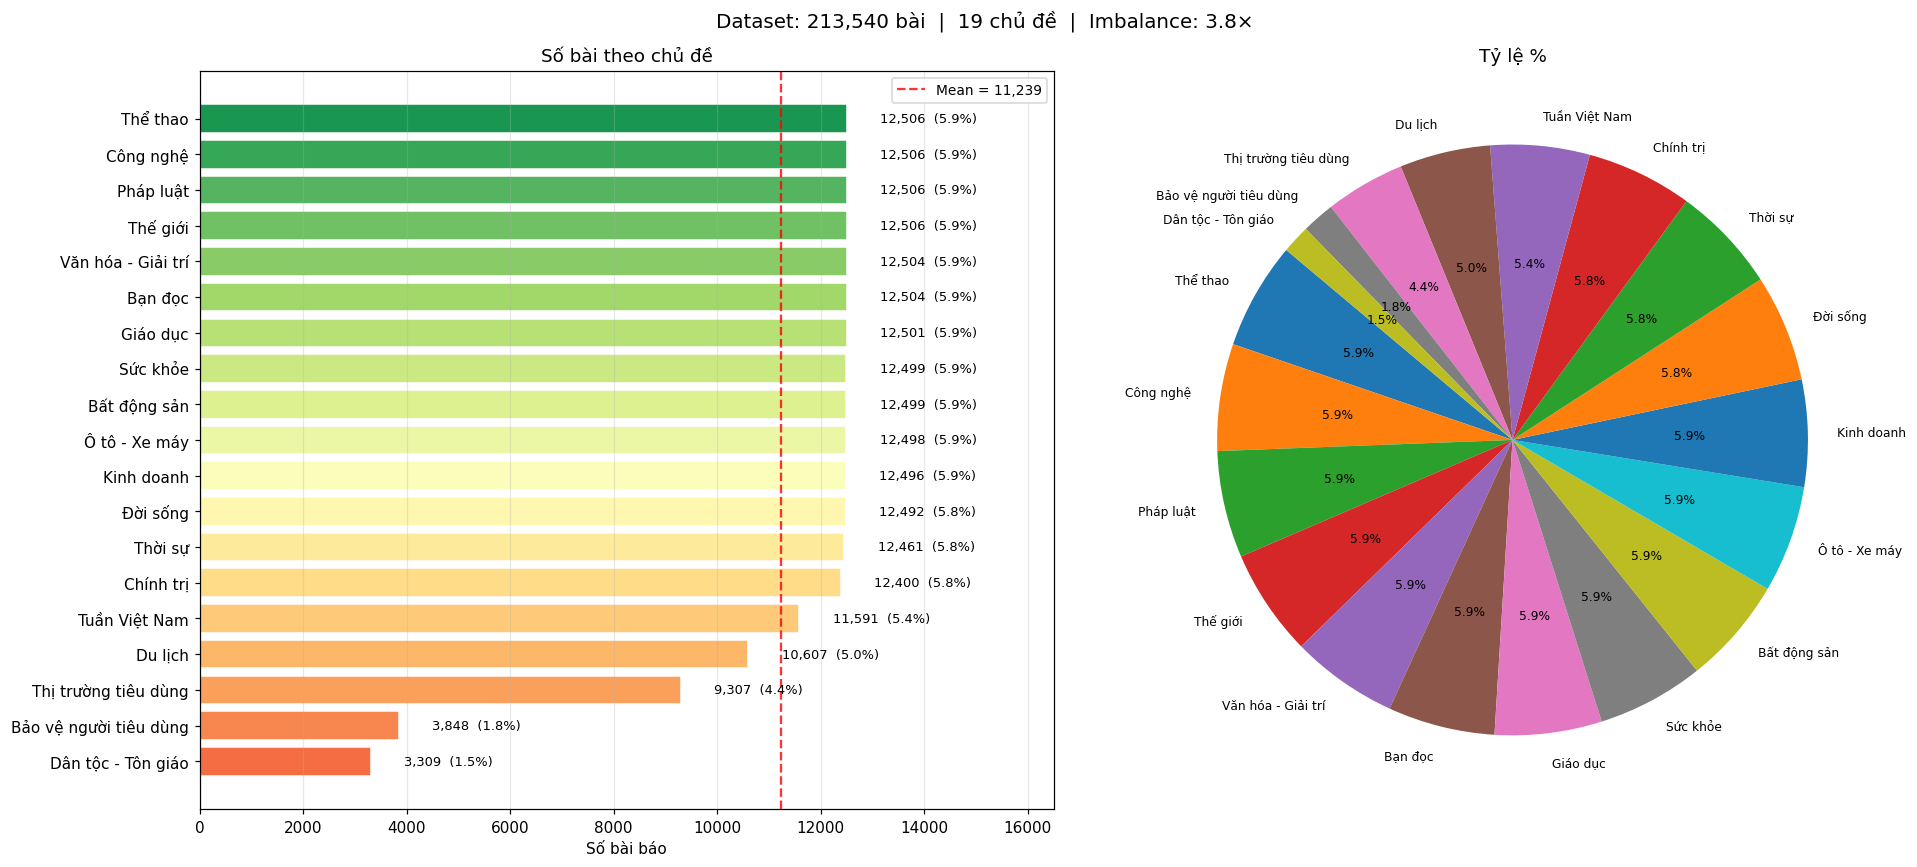

  Nhiều nhất : Thế giới                              12,506
  Ít nhất    : Dân tộc - Tôn giáo                     3,309
  Imbalance  : 3.8×


In [5]:
# ── 2.1 Phân bố class ────────────────────────────────────────────────────────
_vc    = df_raw["label"].value_counts().sort_values(ascending=True)
_total = len(df_raw)
_cmap  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(_vc)))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

_bars = axes[0].barh(_vc.index, _vc.values, color=_cmap, edgecolor="white")
for bar, n in zip(_bars, _vc.values):
    axes[0].text(bar.get_width() + _total*0.003,
                 bar.get_y() + bar.get_height()/2,
                 f"{n:,}  ({n/_total*100:.1f}%)", va="center", fontsize=8.5)
axes[0].set_xlim(0, _vc.max()*1.32)
axes[0].axvline(_vc.mean(), color="red", ls="--", alpha=0.8, label=f"Mean = {_vc.mean():,.0f}")
axes[0].set_xlabel("Số bài báo"); axes[0].set_title("Số bài theo chủ đề", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(axis="x", alpha=0.3)

axes[1].pie(_vc.values[::-1], labels=_vc.index[::-1],
            autopct="%1.1f%%", startangle=140, textprops={"fontsize":8})
axes[1].set_title("Tỷ lệ %", fontweight="bold")

_ir = _vc.max() / _vc.min()
fig.suptitle(f"Dataset: {_total:,} bài  |  {len(_vc)} chủ đề  |  Imbalance: {_ir:.1f}×",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_class_distribution.png")
print(f"  Nhiều nhất : {_vc.idxmax():<35} {_vc.max():>8,}")
print(f"  Ít nhất    : {_vc.idxmin():<35} {_vc.min():>8,}")
print(f"  Imbalance  : {_ir:.1f}×")

[16:53:44][  20.8s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\02_text_length.png


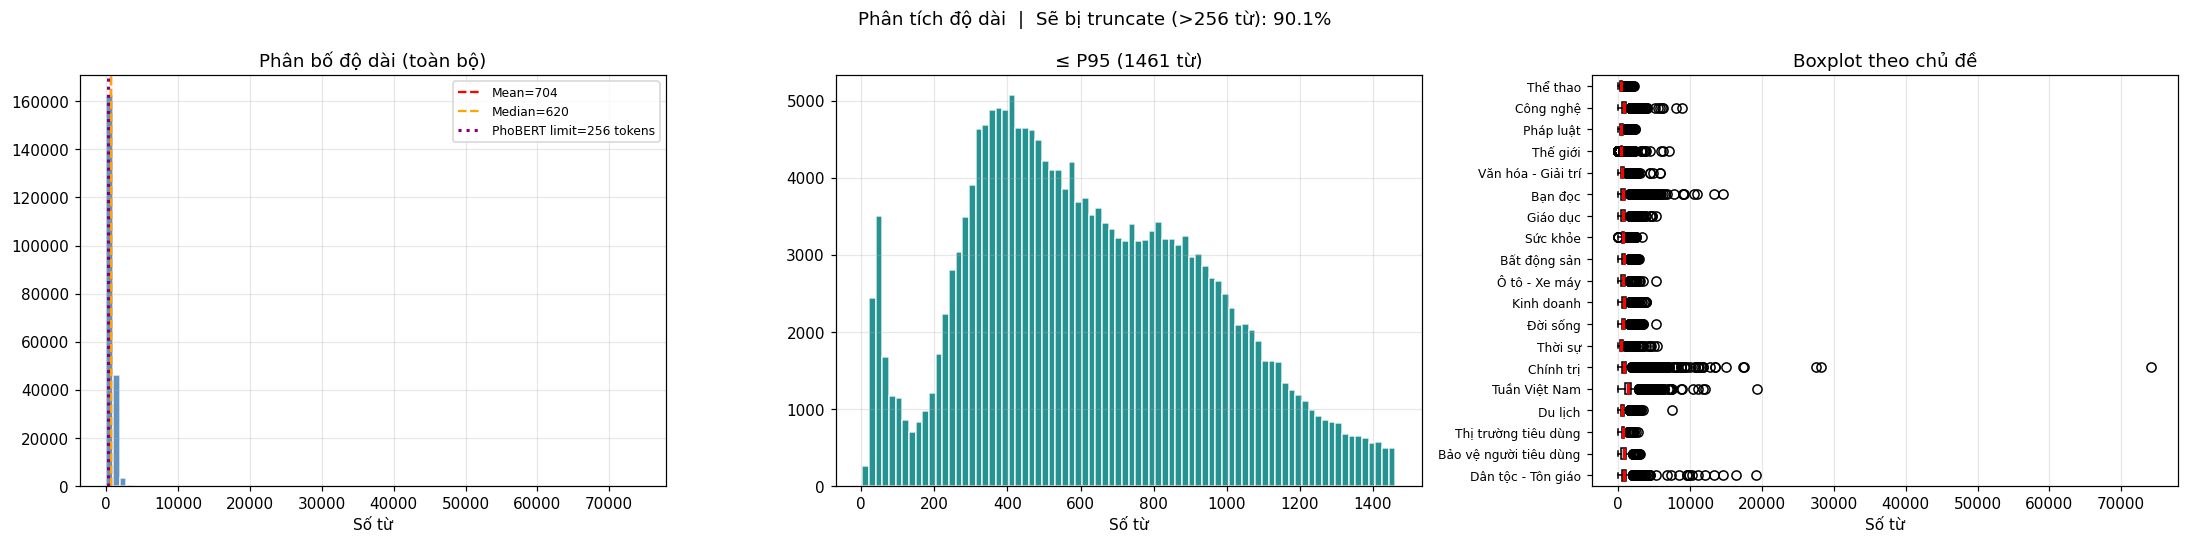

  Min     :      3.0 từ
  Median  :    620.0 từ
  Mean    :    703.9 từ
  P90     :  1,198.0 từ
  P95     :  1,461.0 từ
  Max     : 74,189.0 từ
  Trên 256 từ: 90.1% → dùng Head-Tail để tận dụng cả đầu lẫn cuối bài


In [6]:
# ── 2.2 Phân bố độ dài văn bản ──────────────────────────────────────────────
_lens = df_raw["text_len"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(_lens, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(_lens.mean(),   color="red",    ls="--", lw=1.5, label=f"Mean={_lens.mean():.0f}")
axes[0].axvline(_lens.median(), color="orange", ls="--", lw=1.5, label=f"Median={_lens.median():.0f}")
axes[0].axvline(256, color="purple", ls=":", lw=2, label="PhoBERT limit=256 tokens")
axes[0].set_xlabel("Số từ"); axes[0].set_title("Phân bố độ dài (toàn bộ)", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

_p95 = _lens.quantile(0.95)
axes[1].hist(_lens[_lens <= _p95], bins=80, color="teal", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Số từ"); axes[1].set_title(f"≤ P95 ({_p95:.0f} từ)", fontweight="bold")
axes[1].grid(alpha=0.3)

_cls_ord = list(df_raw["label"].value_counts().sort_values().index)
_lbc = [df_raw[df_raw["label"]==c]["text_len"].values for c in _cls_ord]
bp = axes[2].boxplot(_lbc, vert=False, patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
for patch, color in zip(bp["boxes"], plt.cm.Set3(np.linspace(0, 1, len(_cls_ord)))):
    patch.set_facecolor(color)
axes[2].set_yticks(range(1, len(_cls_ord)+1)); axes[2].set_yticklabels(_cls_ord, fontsize=8)
axes[2].set_xlabel("Số từ"); axes[2].set_title("Boxplot theo chủ đề", fontweight="bold")
axes[2].grid(axis="x", alpha=0.3)

_trunc_pct = (_lens > 256).mean()
fig.suptitle(f"Phân tích độ dài  |  Sẽ bị truncate (>256 từ): {_trunc_pct:.1%}",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_fig(fig, "02_text_length.png")

for _lbl, _v in [("Min",_lens.min()),("Median",_lens.median()),("Mean",_lens.mean()),
                  ("P90",_lens.quantile(.9)),("P95",_lens.quantile(.95)),("Max",_lens.max())]:
    print(f"  {_lbl:<8}: {_v:>8,.1f} từ")
print(f"  Trên 256 từ: {_trunc_pct:.1%} → dùng Head-Tail để tận dụng cả đầu lẫn cuối bài")

In [6]:
# ── 2.3 Bảng tổng hợp dataset ───────────────────────────────────────────────
_rows = []
for _cls in sorted(df_raw["label"].unique()):
    _sub = df_raw[df_raw["label"] == _cls]["text_len"]
    _rows.append({"Chủ đề": _cls, "Số bài": len(_sub),
                  "Tỷ lệ %": round(len(_sub)/len(df_raw)*100, 2),
                  "TB từ": round(_sub.mean(), 0), "Median từ": round(_sub.median(), 0),
                  "Max từ": int(_sub.max())})
_df_sum = pd.DataFrame(_rows).sort_values("Số bài", ascending=False).reset_index(drop=True)
_df_sum.index += 1
print("📊 BẢNG TỔNG HỢP DỮ LIỆU\n")
display(_df_sum.style
    .background_gradient(subset=["Số bài"], cmap="Blues")
    .background_gradient(subset=["TB từ"], cmap="Greens")
    .format({"Số bài":"{:,}", "Tỷ lệ %":"{:.2f}%", "TB từ":"{:.0f}", "Median từ":"{:.0f}"}))

📊 BẢNG TỔNG HỢP DỮ LIỆU



,Chủ đề,Số bài,Tỷ lệ %,TB từ,Median từ,Max từ
1,Thể thao,"12,506",5.86%,396,355,2254
2,Pháp luật,"12,506",5.86%,503,426,2370
3,Công nghệ,"12,506",5.86%,817,791,8938
4,Thế giới,"12,506",5.86%,413,387,7079
5,Văn hóa - Giải trí,"12,504",5.86%,571,503,5810
6,Bạn đọc,"12,504",5.86%,729,713,14648
7,Giáo dục,"12,501",5.85%,699,645,5236
8,Sức khỏe,"12,499",5.85%,632,604,3375
9,Bất động sản,"12,499",5.85%,787,805,2855
10,Ô tô - Xe máy,"12,498",5.85%,694,642,5190


---
## 🔤 Section 3 — Tiền Xử Lý Văn Bản

**Lưu ý PhoBERT**: KHÔNG loại stopwords — BERT tự học contextual meaning.
Chỉ: lowercase → bỏ dấu câu → bỏ số → ViTokenizer (word segmentation).

- Cell 3.1: tokenize toàn bộ corpus, lưu `temp/processed_data.pkl` *(nặng ~20–40 phút; bỏ qua nếu cache đã có)*
- Cell 3.2: load dữ liệu đã xử lý *(luôn chạy)*

In [7]:
# ── 3.1 ViTokenize + Lưu cache ──────────────────────────────────────────────
if os.path.exists(PROCESSED_DATA_PATH):
    print(f"✅ Cache tồn tại: {PROCESSED_DATA_PATH}  — bỏ qua tokenization")
else:
    log("Bắt đầu tiền xử lý văn bản...")

    _df_proc = df_raw[["label"]].copy()
    _df_proc["full_text"] = (df_raw["title"] + " " + df_raw["title"]
                             + " " + df_raw["content"])
    _df_proc = _df_proc[_df_proc["full_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Văn bản hợp lệ: {len(_df_proc):,}", "OK")

    def _clean_one(text):
        '''ViTokenize không có stopwords (PhoBERT tự học context).'''
        from pyvi import ViTokenizer
        import re
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r"[^\w\s]", " ", text)
        text = re.sub(r"\d+",     " ", text)
        text = ViTokenizer.tokenize(text)
        return re.sub(r"\s+", " ", text).strip()

    from joblib import Parallel, delayed
    from multiprocessing import cpu_count
    log(f"Parallel tokenize {len(_df_proc):,} bài | {cpu_count()} CPU cores...")
    _df_proc["clean_text"] = Parallel(n_jobs=-1, backend="loky", verbose=1)(
        delayed(_clean_one)(t) for t in _df_proc["full_text"].tolist()
    )
    _df_proc = _df_proc[_df_proc["clean_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Sau tokenization: {len(_df_proc):,} bài", "OK")

    _classes  = sorted(_df_proc["label"].unique().tolist())
    _label2id = {l: i for i, l in enumerate(_classes)}
    _id2label = {i: l for l, i in _label2id.items()}
    _df_proc["label_id"] = _df_proc["label"].map(_label2id)

    with timer("Lưu processed_data.pkl"):
        with open(PROCESSED_DATA_PATH, "wb") as _f:
            pickle.dump({"df":_df_proc, "label2id":_label2id, "id2label":_id2label}, _f)
    log(f"Saved ({os.path.getsize(PROCESSED_DATA_PATH)/1e6:.1f} MB)", "SAVE")

✅ Cache tồn tại: d:\Vietnamnet_News_Classification\PhoBERT\temp\processed_data.pkl  — bỏ qua tokenization


In [8]:
# ── 3.2 Load processed data (luôn chạy) ──────────────────────────────────────
with timer("Load processed_data.pkl"):
    with open(PROCESSED_DATA_PATH, "rb") as f:
        _s = pickle.load(f)

df       = _s["df"]
label2id = _s["label2id"]
id2label = _s["id2label"]
classes  = sorted(df["label"].unique().tolist())
N_CLASSES = len(classes)

_vc3 = df["label"].value_counts()
print(f"✅ Processed data: {len(df):,} bài | {N_CLASSES} chủ đề\n")
print(f"   {'Chủ đề':<38}  {'Bài':>8}  {'%':>5}  TB tokens (ViTokenizer)")
print(f"   {'─'*62}")
for _cls in classes:
    _n   = _vc3.get(_cls, 0)
    _tl  = df[df["label"]==_cls]["clean_text"].str.split().str.len().mean()
    print(f"   {_cls:<38}  {_n:>8,}  {_n/len(df)*100:>4.1f}%  {_tl:>6.0f}")

[16:53:56][  32.9s] ✅ Load processed_data.pkl — 5.1s
✅ Processed data: 213,540 bài | 19 chủ đề

   Chủ đề                                       Bài      %  TB tokens (ViTokenizer)
   ──────────────────────────────────────────────────────────────
   Bạn đọc                                   12,504   5.9%     578
   Bảo vệ người tiêu dùng                     3,848   1.8%     610
   Bất động sản                              12,499   5.9%     584
   Chính trị                                 12,400   5.8%     676
   Công nghệ                                 12,506   5.9%     596
   Du lịch                                   10,607   5.0%     497
   Dân tộc - Tôn giáo                         3,309   1.5%     676
   Giáo dục                                  12,501   5.9%     519
   Kinh doanh                                12,496   5.9%     599
   Pháp luật                                 12,506   5.9%     387
   Sức khỏe                                  12,499   5.9%     477
   Thế giới      

---
## 🔢 Section 4 — Tokenize Head-Tail + Train/Test Split

**Chiến lược Head-Tail**: lấy 127 token đầu + 127 token cuối → tổng 256 (bao gồm [CLS] và [SEP]).
Hiệu quả khi bài báo dài — giữ được thông tin cả phần mở bài lẫn kết luận.

In [9]:
# ── 4.1 Định nghĩa Dataset + Helper classes ──────────────────────────────────
class HeadTailDataset(TorchDataset):
    '''Head+Tail: 127 token đầu + 127 token cuối (+ [CLS] + [SEP] = 256).'''
    def __init__(self, texts, labels, tokenizer, label2id):
        self.labels     = [label2id[l] for l in labels]
        self.input_ids  = []
        self.attn_masks = []
        half   = (MAX_LENGTH - 2) // 2
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id

        for text in tqdm(texts.tolist(), desc="  HeadTail tokenize", ncols=80, leave=True):
            tokens = tokenizer.encode(text, add_special_tokens=False, truncation=False)
            if len(tokens) <= MAX_LENGTH - 2:
                enc  = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH)
                ids  = enc["input_ids"]
                attn = enc["attention_mask"]
            else:
                head  = tokens[:half]
                tail  = tokens[-half:]
                ids   = [cls_id] + head + tail + [sep_id]
                attn  = [1] * len(ids)
                pad_n = MAX_LENGTH - len(ids)
                ids  += [pad_id] * pad_n
                attn += [0]     * pad_n
            self.input_ids.append(ids)
            self.attn_masks.append(attn)

        # Chuyển list → stacked tensors ngay sau tokenize
        # __getitem__ chỉ cần tensor indexing — không tạo tensor mới mỗi sample
        self._to_tensors()

    def _to_tensors(self):
        '''Chuyển Python lists → stacked tensors. Gọi sau khi load cache cũ format.'''
        if isinstance(self.input_ids, list):
            self.input_ids  = torch.tensor(self.input_ids,  dtype=torch.long)
            self.attn_masks = torch.tensor(self.attn_masks, dtype=torch.long)
            self.labels     = torch.tensor(self.labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attn_masks[idx],
            "labels":         self.labels[idx],
        }


class WeightedTrainer(Trainer):
    '''Trainer với weighted cross-entropy để xử lý mất cân bằng class.'''
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss    = torch.nn.functional.cross_entropy(logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


class EpochCallback(TrainerCallback):
    '''Log chi tiết sau mỗi epoch + thời gian thực mỗi logging_steps.'''
    def __init__(self):
        self._train_start  = None
        self._epoch_start  = None
        self._total_steps  = None

    def on_train_begin(self, args, state, control, **kwargs):
        self._train_start = time.time()
        self._total_steps = state.max_steps
        log(f"Tổng steps: {self._total_steps:,}  |  {NUM_EPOCHS} epochs  |  "
            f"~{self._total_steps//NUM_EPOCHS:,} steps/epoch", "OK")

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()
        ep = int(state.epoch) + 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        log(f"{'─'*50}")
        log(f"EPOCH {ep}/{NUM_EPOCHS} — bắt đầu  |  Đã chạy: {elapsed/60:.1f} phút")
        gpu_status()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs: return
        step    = state.global_step
        total   = self._total_steps or 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        eta_sec = (elapsed / step * (total - step)) if step > 0 else 0
        spd     = logs.get("train_samples_per_second", 0)
        spd_str = f"  |  {spd:.0f} samples/s" if spd else ""
        log(f"step {step:>5}/{total}  [{step/total*100:4.1f}%]  "
            f"loss={logs['loss']:.4f}  lr={logs.get('learning_rate',0):.2e}  "
            f"elapsed={elapsed/60:.1f}m  ETA={eta_sec/60:.1f}m{spd_str}")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        acc   = metrics.get("eval_accuracy",    0)
        f1_w  = metrics.get("eval_f1_weighted", 0)
        f1_m  = metrics.get("eval_f1_macro",    0)
        eloss = metrics.get("eval_loss",        0)
        ep_t  = time.time() - self._epoch_start if self._epoch_start else 0
        total_t = time.time() - self._train_start if self._train_start else 0
        log(f"EPOCH {state.epoch:.0f} DONE  |  Loss={eloss:.4f}  Acc={acc:.4f}  "
            f"F1-w={f1_w:.4f}  F1-m={f1_m:.4f}  "
            f"(epoch {ep_t/60:.1f}m  /  tổng {total_t/60:.1f}m)", "OK")

print("✅ Dataset classes và WeightedTrainer định nghĩa xong.")

✅ Dataset classes và WeightedTrainer định nghĩa xong.


In [10]:
# ── 4.2 Train/test split + Tạo HeadTail datasets ────────────────────────────
log("Train/test split (stratified)...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["label"]
)
log(f"Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}", "OK")

# Load PhoBERT tokenizer
log(f"Load tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Thống kê token length trên sample
_sample_text = df["clean_text"].sample(min(1000, len(df)), random_state=RANDOM_STATE).tolist()
_tlen = np.array([len(tokenizer.encode(t, truncation=False)) for t in
                  tqdm(_sample_text, desc="  Token length check", ncols=80)])
log(f"Token length — mean={_tlen.mean():.1f} | median={np.median(_tlen):.1f} | "
    f"max={_tlen.max()} | >256: {(_tlen>256).mean():.1%}", "OK")

# Tính class weights
log("Tính class weights (balanced)...")
_cw_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=[label2id[l] for l in y_train],
)
class_weights = torch.tensor(_cw_vals, dtype=torch.float32)
print(f"\n   {'Chủ đề':<38}  {'Weight':>8}")
print(f"   {'─'*48}")
for i, cls in enumerate(classes):
    print(f"   {cls:<38}  {_cw_vals[i]:>8.4f}")

# ── Cache HeadTail datasets để tránh tokenize lại ────────────────────────────
_HT_TRAIN_CACHE = os.path.join(TEMP_DIR, "headtail_train.pkl")
_HT_TEST_CACHE  = os.path.join(TEMP_DIR, "headtail_test.pkl")

if os.path.exists(_HT_TRAIN_CACHE) and os.path.exists(_HT_TEST_CACHE):
    log("Load HeadTail datasets từ cache...", "OK")
    with timer("Load train cache"):
        with open(_HT_TRAIN_CACHE, "rb") as f:
            train_dataset = pickle.load(f)
    with timer("Load test cache"):
        with open(_HT_TEST_CACHE, "rb") as f:
            test_dataset = pickle.load(f)
    # Cache cũ lưu lists → chuyển sang stacked tensors để __getitem__ nhanh hơn
    train_dataset._to_tensors()
    test_dataset._to_tensors()
    log("HeadTail datasets loaded từ cache", "OK")
else:
    log("Tạo HeadTail train dataset (lần đầu — sẽ cache lại)...")
    with timer("Train HeadTail"):
        train_dataset = HeadTailDataset(X_train_raw, y_train, tokenizer, label2id)
    with timer("Lưu train cache"):
        with open(_HT_TRAIN_CACHE, "wb") as f:
            pickle.dump(train_dataset, f)
    log(f"Saved train cache ({os.path.getsize(_HT_TRAIN_CACHE)/1e6:.0f} MB)", "SAVE")

    log("Tạo HeadTail test dataset...")
    with timer("Test HeadTail"):
        test_dataset = HeadTailDataset(X_test_raw, y_test, tokenizer, label2id)
    with timer("Lưu test cache"):
        with open(_HT_TEST_CACHE, "wb") as f:
            pickle.dump(test_dataset, f)
    log(f"Saved test cache ({os.path.getsize(_HT_TEST_CACHE)/1e6:.0f} MB)", "SAVE")

log(f"Train: {len(train_dataset):,} samples  |  Test: {len(test_dataset):,} samples", "OK")
log(f"Input IDs shape: {train_dataset.input_ids.shape}  dtype={train_dataset.input_ids.dtype}", "OK")
log(f"💡 Xóa cache khi không cần: {_HT_TRAIN_CACHE}", "INFO")
gpu_status()

[16:54:16][  52.8s] ℹ️ Train/test split (stratified)...
[16:54:16][  52.9s] ✅ Train: 181,509  |  Test: 32,031
[16:54:16][  52.9s] ℹ️ Load tokenizer: vinai/phobert-large...


  Token length check: 100%|████████████████| 1000/1000 [00:01<00:00, 541.71it/s]

[16:54:20][  56.7s] ✅ Token length — mean=600.2 | median=539.5 | max=4066 | >256: 89.0%
[16:54:20][  56.7s] ℹ️ Tính class weights (balanced)...



   Chủ đề                                    Weight
   ────────────────────────────────────────────────
   Bạn đọc                                   0.8988
   Bảo vệ người tiêu dùng                    2.9205
   Bất động sản                              0.8992
   Chính trị                                 0.9064
   Công nghệ                                 0.8987
   Du lịch                                   1.0596
   Dân tộc - Tôn giáo                        3.3961
   Giáo dục                                  0.8990
   Kinh doanh                                0.8994
   Pháp luật                                 0.8987
   Sức khỏe                                  0.8992
   Thế giới                                  0.8987
   Thể thao                                  0.8987
   Thị trường tiêu dùng                      1.2076
   Thời sự                                   0.9019
   Tuần Việt Nam                             0.9697
   Văn hóa - Giải trí                        0.8989
   Ô tô - X

---
## 🤖 Section 5 — Huấn Luyện Mô Hình

**PhoBERT Large** fine-tuning với Hugging Face Trainer.

| Tham số | Giá trị | Lý do |
|---------|---------|-------|
| `LR` | 1e-5 | Tránh catastrophic forgetting với pretrained model |
| `batch` | 16 × accum 4 = eff 64 | Safe cho 24GB VRAM |
| `class_weight` | balanced | Dataset mất cân bằng |
| `BF16` | True | RTX 4090 Ada Lovelace hỗ trợ native BF16 |
| `gradient_checkpointing` | True | Giảm VRAM cho large model |

- Cell 5.1: training *(bỏ qua nếu `model/config.json` đã tồn tại)*
- Cell 5.2: load kết quả *(luôn chạy)*

In [11]:
# ── 5.1 Train PhoBERT + Lưu model ───────────────────────────────────────────
_MODEL_READY = os.path.exists(os.path.join(MODEL_DIR, "config.json"))
_CKPT_DIR    = os.path.join(TEMP_DIR, "checkpoints")

if _MODEL_READY:
    log(f"Model đã tồn tại: {MODEL_DIR}  — bỏ qua training", "OK")
else:
    torch.cuda.empty_cache()
    log(f"Load PhoBERT Large: {MODEL_NAME}...")

    def make_compute_metrics():
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            return {
                "accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro"),
            }
        return compute_metrics

    model_train = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=N_CLASSES,
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(device)

    # Fix LayerNorm beta/gamma (PhoBERT checkpoint cũ)
    _sd = model_train.state_dict()
    _new_sd = {}
    for k, v in _sd.items():
        if k.endswith(".beta"):    _new_sd[k.replace(".beta",  ".bias")]   = v
        elif k.endswith(".gamma"): _new_sd[k.replace(".gamma", ".weight")] = v
        else:                      _new_sd[k] = v
    model_train.load_state_dict(_new_sd, strict=False)

    log(f"Params: {sum(p.numel() for p in model_train.parameters())/1e6:.1f}M", "OK")
    gpu_status()

    training_args = TrainingArguments(
        output_dir=_CKPT_DIR,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,       # 64
        per_device_eval_batch_size=EVAL_BATCH,        # 128
        gradient_accumulation_steps=GRAD_ACCUM,       # 1
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        bf16=BF16,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        # num_workers=0: bắt buộc trên Windows (Python 3.14 spawn multiprocessing
        # crash với large tensors trong worker). Dataset đã dùng stacked tensors
        # nên __getitem__ rất nhanh — bottleneck là GPU chứ không phải CPU.
        dataloader_num_workers=0,
        dataloader_pin_memory=True,
        gradient_checkpointing=False,                 # OFF — đủ VRAM 24GB
        optim="adamw_torch_fused",                    # ~15% nhanh hơn optimizer step
        torch_compile=False,                          # Python 3.14+ chưa hỗ trợ
    )

    trainer = WeightedTrainer(
        model=model_train,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=make_compute_metrics(),
        class_weights=class_weights,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
            EpochCallback(),
        ],
    )

    log("🔥 Bắt đầu fine-tuning PhoBERT Large...")
    _t_start = time.time()
    trainer.train()
    _train_time = time.time() - _t_start
    log(f"Training xong — {_train_time:.0f}s ({_train_time/60:.1f} phút)", "OK")
    gpu_status()

    # Lưu model + tokenizer
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)
    log(f"Model saved: {MODEL_DIR}", "SAVE")

    # Lưu training history
    with open(TRAIN_HISTORY_PATH, "wb") as f:
        pickle.dump({"log_history": trainer.state.log_history,
                     "train_time_sec": _train_time}, f)
    log(f"Train history saved: {TRAIN_HISTORY_PATH}", "SAVE")

    # Dọn checkpoints
    if os.path.exists(_CKPT_DIR):
        shutil.rmtree(_CKPT_DIR)
    del model_train, trainer
    torch.cuda.empty_cache()
    log("VRAM đã giải phóng", "OK")

[14:59:05][  38.1s] ℹ️ Load PhoBERT Large: vinai/phobert-large...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 69470.50it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

[14:59:08][  41.1s] ✅ Params: 369.2M
[14:59:08][  41.1s] 🖥️ VRAM: 1.4GB used / 1.4GB reserved / 22.6GB free
[14:59:08][  41.2s] ℹ️ 🔥 Bắt đầu fine-tuning PhoBERT Large...
[14:59:08][  41.3s] ✅ Tổng steps: 14,185  |  5 epochs  |  ~2,837 steps/epoch
[14:59:08][  41.3s] ℹ️ ──────────────────────────────────────────────────
[14:59:08][  41.3s] ℹ️ EPOCH 1/5 — bắt đầu  |  Đã chạy: 0.0 phút
[14:59:08][  41.3s] 🖥️ VRAM: 1.4GB used / 1.4GB reserved / 22.6GB free


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.346867,0.300651,0.906559,0.906716,0.897775
2,0.251479,0.256554,0.917549,0.917941,0.910100
3,0.175104,0.237327,0.925416,0.925717,0.919857
4,0.127127,0.241044,0.930037,0.930017,0.925304
5,0.101433,0.247889,0.930942,0.931098,0.926150


[14:59:46][  79.0s] ℹ️ step   100/14185  [ 0.7%]  loss=2.9411  lr=4.95e-06  elapsed=0.6m  ETA=88.3m
[15:00:23][ 116.2s] ℹ️ step   200/14185  [ 1.4%]  loss=2.1280  lr=9.95e-06  elapsed=1.2m  ETA=87.2m
[15:01:00][ 153.4s] ℹ️ step   300/14185  [ 2.1%]  loss=0.9994  lr=9.93e-06  elapsed=1.9m  ETA=86.4m
[15:01:37][ 190.6s] ℹ️ step   400/14185  [ 2.8%]  loss=0.7259  lr=9.86e-06  elapsed=2.5m  ETA=85.7m
[15:02:15][ 227.8s] ℹ️ step   500/14185  [ 3.5%]  loss=0.6101  lr=9.79e-06  elapsed=3.1m  ETA=85.1m
[15:02:52][ 265.1s] ℹ️ step   600/14185  [ 4.2%]  loss=0.5553  lr=9.71e-06  elapsed=3.7m  ETA=84.4m
[15:03:29][ 302.6s] ℹ️ step   700/14185  [ 4.9%]  loss=0.5269  lr=9.64e-06  elapsed=4.4m  ETA=83.9m
[15:04:07][ 340.3s] ℹ️ step   800/14185  [ 5.6%]  loss=0.4956  lr=9.57e-06  elapsed=5.0m  ETA=83.4m
[15:04:45][ 378.2s] ℹ️ step   900/14185  [ 6.3%]  loss=0.4615  lr=9.50e-06  elapsed=5.6m  ETA=82.9m
[15:05:23][ 416.0s] ℹ️ step  1000/14185  [ 7.0%]  loss=0.4464  lr=9.43e-06  elapsed=6.2m  ETA=82.3m


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

[16:32:00][5613.4s] ✅ Training xong — 5572s (92.9 phút)
[16:32:00][5613.4s] 🖥️ VRAM: 4.1GB used / 21.8GB reserved / 2.2GB free


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]

[16:32:01][5614.1s] 💾 Model saved: d:\Vietnamnet_News_Classification\PhoBERT\model
[16:32:01][5614.1s] 💾 Train history saved: d:\Vietnamnet_News_Classification\PhoBERT\model\train_history.pkl


[16:32:01][5614.5s] ✅ VRAM đã giải phóng


In [12]:
# ── 5.2 Load model + Predict test set (luôn chạy) ───────────────────────────
log(f"Load model từ {MODEL_DIR}...")
model_eval = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=N_CLASSES,
    id2label=id2label,
    label2id=label2id,
).to(device)
model_eval.eval()

def make_compute_metrics():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {"accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro")}
    return compute_metrics

_eval_args = TrainingArguments(
    output_dir=TEMP_DIR, per_device_eval_batch_size=EVAL_BATCH,
    bf16=BF16, report_to="none",
    dataloader_num_workers=0,       # Windows: spawn multiprocessing crash với num_workers>0
    dataloader_pin_memory=True,
)
_eval_trainer = Trainer(
    model=model_eval, args=_eval_args,
    eval_dataset=test_dataset, compute_metrics=make_compute_metrics(),
)

log("Predict test set...")
with timer("Inference"):
    _raw = _eval_trainer.predict(test_dataset)

y_pred_ids  = np.argmax(_raw.predictions, axis=1).tolist()
y_true_ids  = [label2id[l] for l in y_test]
raw_logits  = _raw.predictions

model_acc   = accuracy_score(y_true_ids, y_pred_ids)
model_f1w   = f1_score(y_true_ids, y_pred_ids, average="weighted")
model_f1m   = f1_score(y_true_ids, y_pred_ids, average="macro")
f1_per_class= dict(zip(classes, f1_score(y_true_ids, y_pred_ids,
                                          labels=list(range(N_CLASSES)), average=None)))

# Load training history nếu có
log_history = []
train_time_sec = 0
if os.path.exists(TRAIN_HISTORY_PATH):
    with open(TRAIN_HISTORY_PATH, "rb") as f:
        _hist = pickle.load(f)
    log_history    = _hist.get("log_history", [])
    train_time_sec = _hist.get("train_time_sec", 0)

print(f"\n{'='*55}")
print(f"  PhoBERT Large — Head-Tail")
print(f"  {'─'*52}")
print(f"  Accuracy   : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
if train_time_sec:
    print(f"  Train time : {train_time_sec/60:.1f} phút")
print(f"{'='*55}")
gpu_status()

[16:54:42][  78.9s] ℹ️ Load model từ d:\Vietnamnet_News_Classification\PhoBERT\model...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 16458.27it/s]


[16:54:43][  79.7s] ℹ️ Predict test set...


[16:55:34][ 130.6s] ✅ Inference — 50.9s

  PhoBERT Large — Head-Tail
  ────────────────────────────────────────────────────
  Accuracy   : 0.9309  (93.09%)
  F1-weighted: 0.9311
  F1-macro   : 0.9261
  Train time : 92.9 phút
[16:55:34][ 130.6s] 🖥️ VRAM: 1.4GB used / 3.3GB reserved / 20.7GB free


---
## 📈 Section 6 — Đánh Giá Mô Hình

Classification report, confusion matrix, F1 từng chủ đề, training curves.

In [13]:
# ── 6.1 Classification Report ────────────────────────────────────────────────
_report_str = classification_report(y_true_ids, y_pred_ids, target_names=classes, digits=4)

print(f"{'='*65}")
print(f"  CLASSIFICATION REPORT — PhoBERT Large Head-Tail")
print(f"  {'─'*62}")
print(f"  Accuracy   : {model_acc:.4f}")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
print(f"{'='*65}")
print(_report_str)

_rp = os.path.join(RESULTS_DIR, "classification_report.txt")
with open(_rp, "w", encoding="utf-8") as f:
    f.write(f"PhoBERT Large — Head-Tail\n")
    f.write(f"Accuracy:    {model_acc:.4f}\n")
    f.write(f"F1-weighted: {model_f1w:.4f}\n")
    f.write(f"F1-macro:    {model_f1m:.4f}\n\n")
    f.write(_report_str)
log(f"Saved: {_rp}", "SAVE")

  CLASSIFICATION REPORT — PhoBERT Large Head-Tail
  ──────────────────────────────────────────────────────────────
  Accuracy   : 0.9309
  F1-weighted: 0.9311
  F1-macro   : 0.9261
                        precision    recall  f1-score   support

               Bạn đọc     0.9656    0.9723    0.9689      1875
Bảo vệ người tiêu dùng     0.9176    0.9653    0.9409       577
          Bất động sản     0.9354    0.9419    0.9386      1875
             Chính trị     0.9374    0.9177    0.9275      1860
             Công nghệ     0.9324    0.9259    0.9291      1876
               Du lịch     0.9113    0.9107    0.9110      1591
    Dân tộc - Tôn giáo     0.7593    0.9032    0.8250       496
              Giáo dục     0.9452    0.9483    0.9468      1875
            Kinh doanh     0.8858    0.8234    0.8534      1874
             Pháp luật     0.9139    0.9222    0.9180      1876
              Sức khỏe     0.9771    0.9579    0.9674      1875
              Thế giới     0.9803    0.9819    0.9

[16:55:41][ 138.2s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\03_confusion_matrix.png


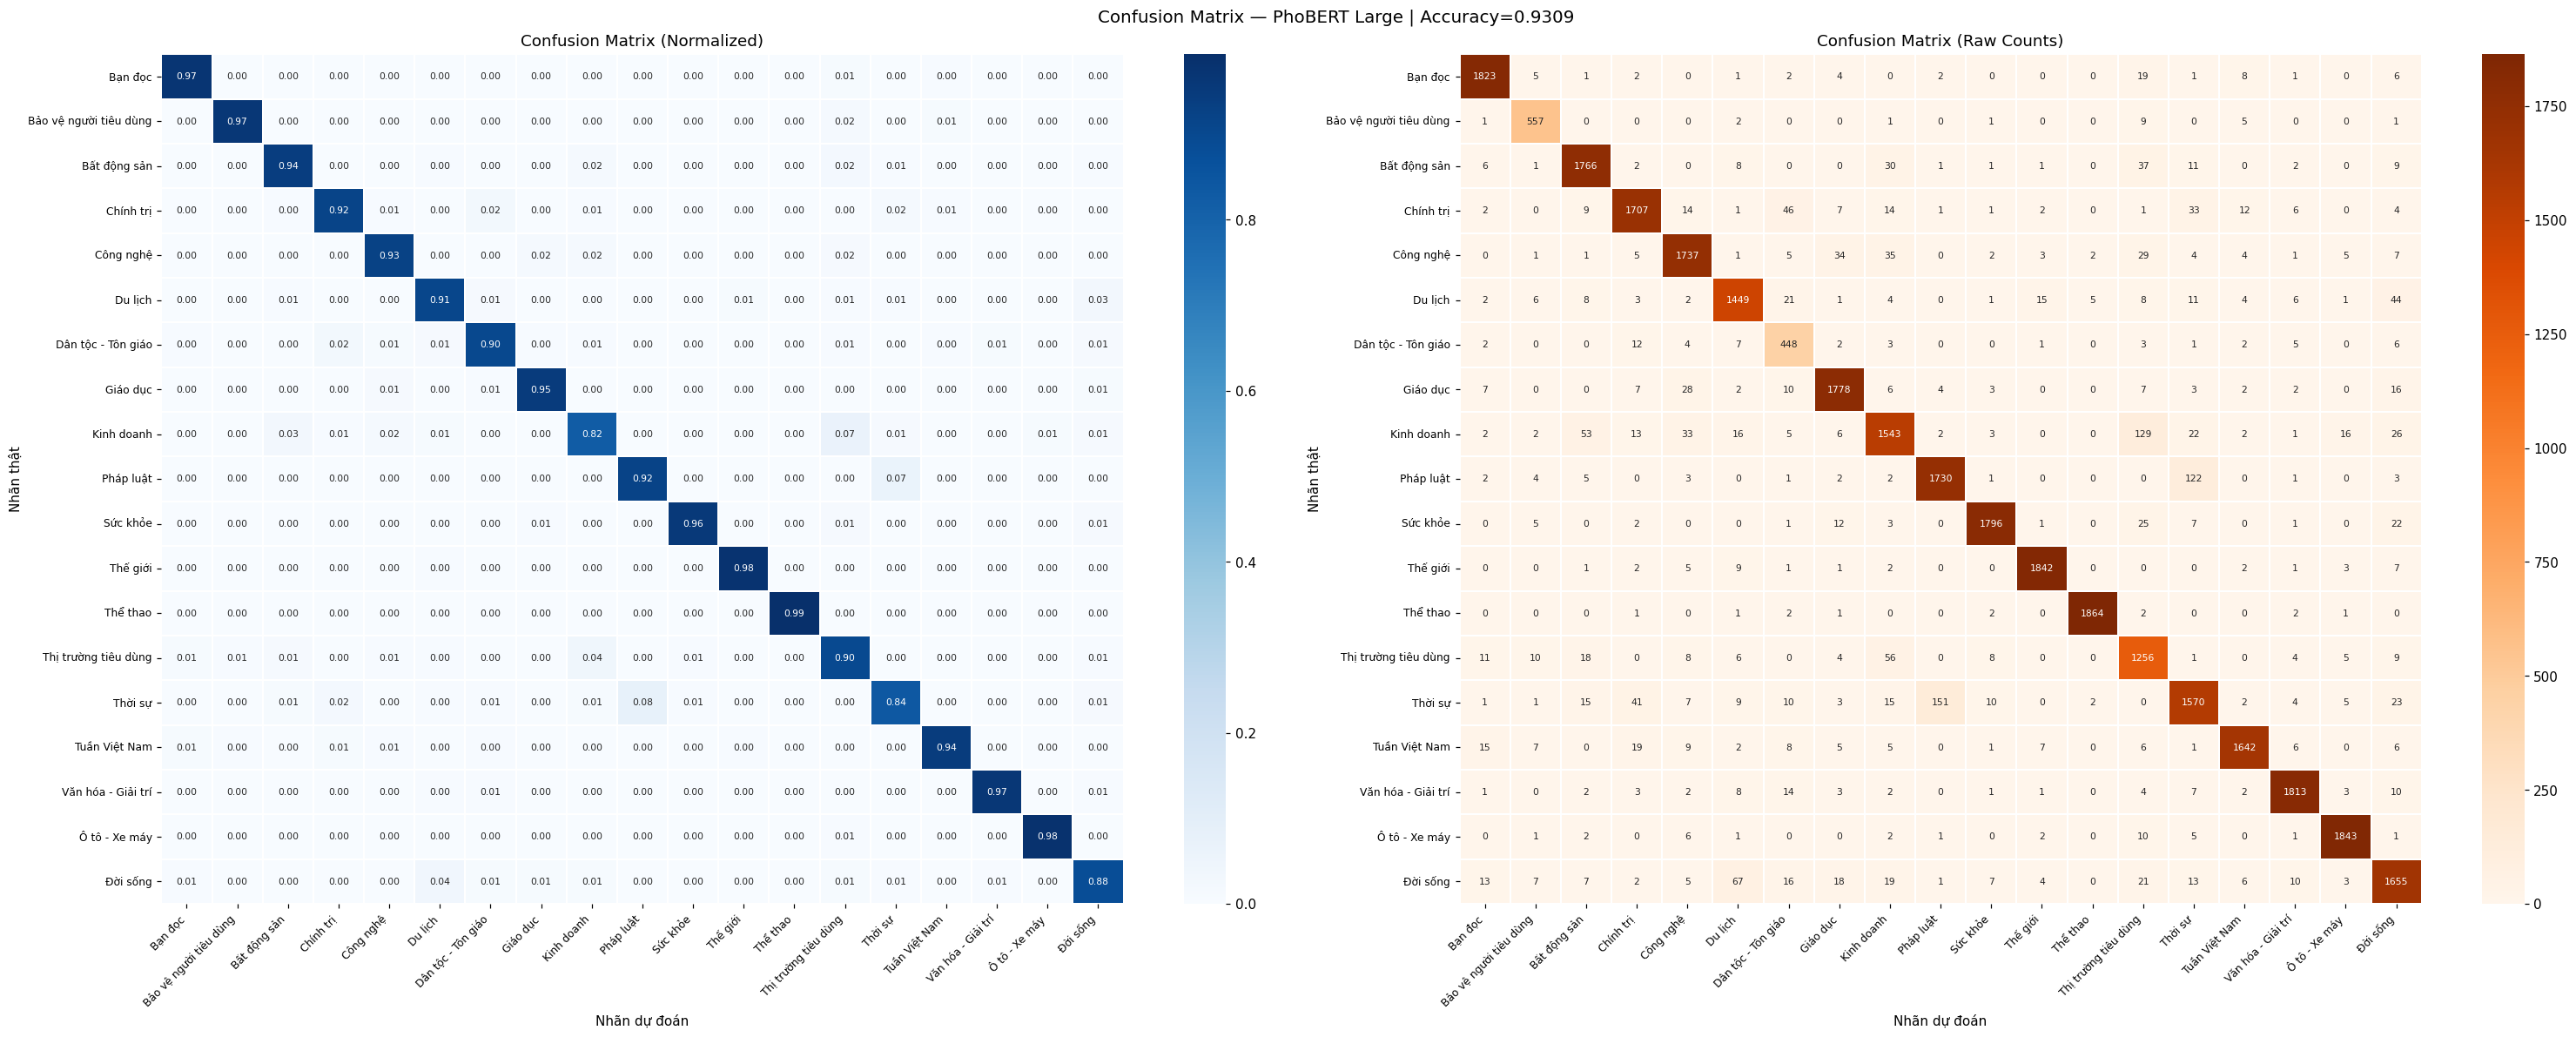

In [14]:
# ── 6.2 Confusion Matrix ─────────────────────────────────────────────────────
_cm   = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_cmn  = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(28, 11))
for ax, data, fmt, cmap, title in [
    (axes[0], _cmn, ".2f", "Blues",   "Normalized"),
    (axes[1], _cm,  "d",   "Oranges", "Raw Counts"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.3, linecolor="white", ax=ax, annot_kws={"size":7})
    ax.set_xlabel("Nhãn dự đoán", fontsize=10)
    ax.set_ylabel("Nhãn thật",    fontsize=10)
    ax.set_title(f"Confusion Matrix ({title})", fontsize=12, fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

fig.suptitle(f"Confusion Matrix — PhoBERT Large | Accuracy={model_acc:.4f}",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_confusion_matrix.png")

[16:55:44][ 141.0s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\04_f1_per_class.png


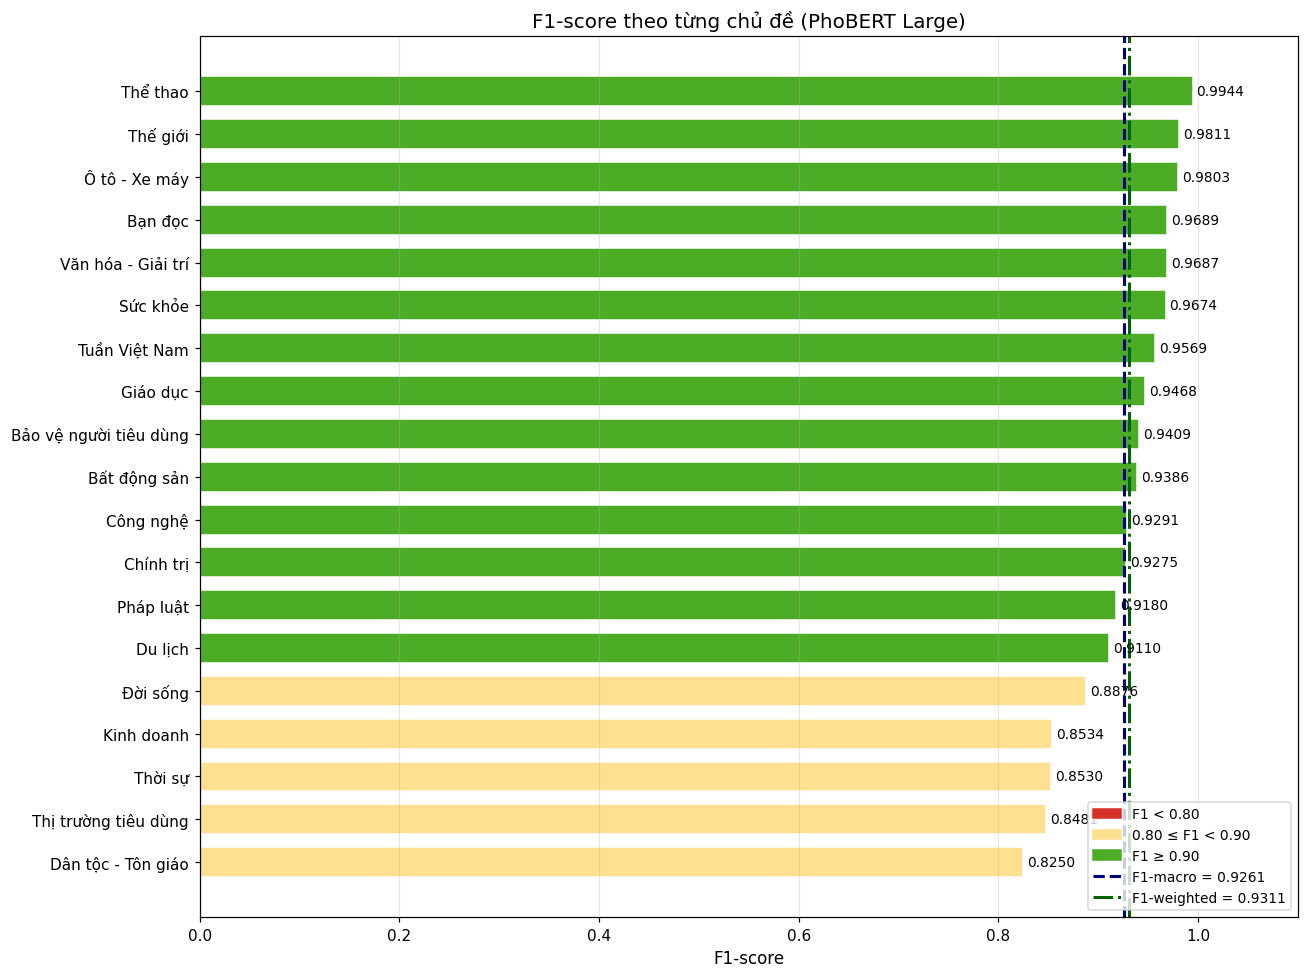

In [15]:
# ── 6.3 F1-score theo từng chủ đề ────────────────────────────────────────────
_f1_items = sorted(f1_per_class.items(), key=lambda x: x[1])
_cls_names = [x[0] for x in _f1_items]
_cls_f1    = [x[1] for x in _f1_items]
_colors    = ["#d73027" if v < 0.80 else "#fee090" if v < 0.90 else "#4dac26" for v in _cls_f1]

fig, ax = plt.subplots(figsize=(12, 9))
_bars = ax.barh(_cls_names, _cls_f1, color=_colors, edgecolor="white", height=0.7)
for bar, v in zip(_bars, _cls_f1):
    ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=9)

ax.axvline(model_f1m, color="navy",      ls="--", lw=2, label=f"F1-macro = {model_f1m:.4f}")
ax.axvline(model_f1w, color="darkgreen", ls="-.", lw=2, label=f"F1-weighted = {model_f1w:.4f}")
ax.set_xlim(0, 1.10); ax.set_xlabel("F1-score", fontsize=11)
ax.set_title("F1-score theo từng chủ đề (PhoBERT Large)", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[
    Patch(color="#d73027", label="F1 < 0.80"),
    Patch(color="#fee090", label="0.80 ≤ F1 < 0.90"),
    Patch(color="#4dac26", label="F1 ≥ 0.90"),
    plt.Line2D([0],[0], color="navy",      ls="--", lw=2, label=f"F1-macro = {model_f1m:.4f}"),
    plt.Line2D([0],[0], color="darkgreen", ls="-.", lw=2, label=f"F1-weighted = {model_f1w:.4f}"),
], fontsize=9, loc="lower right")
fig.tight_layout()
save_fig(fig, "04_f1_per_class.png")

[16:55:48][ 144.6s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\05_training_curves.png


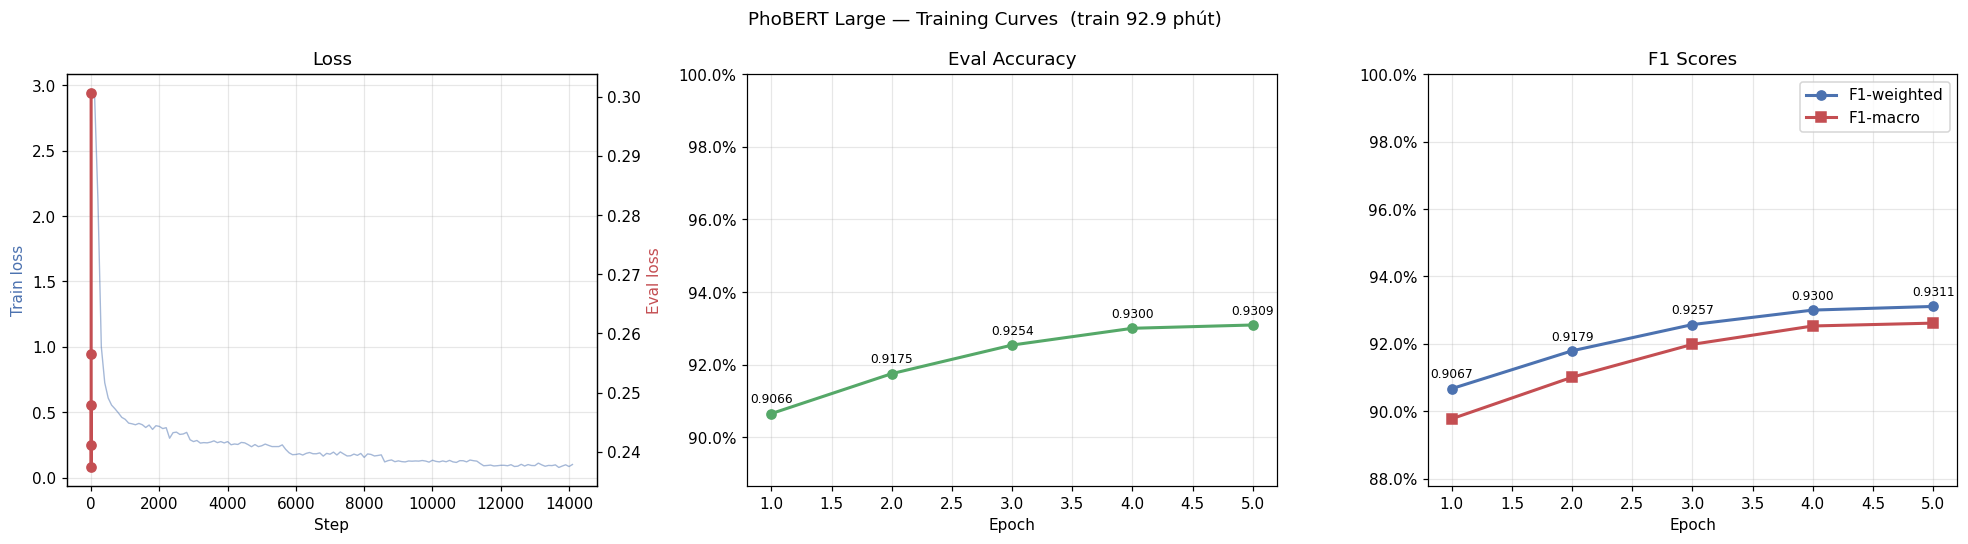

In [16]:
# ── 6.4 Training Curves ──────────────────────────────────────────────────────
if not log_history:
    print("⚠️  Không có log_history (model load từ cache). Bỏ qua training curves.")
else:
    _train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    _eval_logs  = [x for x in log_history if "eval_loss" in x]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot([x["step"] for x in _train_logs], [x["loss"] for x in _train_logs],
                 alpha=0.5, color="#4C72B0", lw=0.9, label="Train loss")
    _ax2 = axes[0].twinx()
    _ax2.plot([x["epoch"] for x in _eval_logs], [x["eval_loss"] for x in _eval_logs],
              marker="o", color="#C44E52", lw=2, label="Eval loss")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Train loss", color="#4C72B0")
    _ax2.set_ylabel("Eval loss", color="#C44E52"); axes[0].set_title("Loss"); axes[0].grid(alpha=0.3)

    # Accuracy
    _ep = [x["epoch"] for x in _eval_logs]
    _ac = [x.get("eval_accuracy",0) for x in _eval_logs]
    axes[1].plot(_ep, _ac, marker="o", color="#55A868", lw=2)
    for x, y in zip(_ep, _ac):
        axes[1].annotate(f"{y:.4f}", (x,y), textcoords="offset points", xytext=(0,7),
                         ha="center", fontsize=8)
    axes[1].set_xlabel("Epoch"); axes[1].set_title("Eval Accuracy", fontweight="bold")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1].set_ylim(max(0.7, min(_ac)-0.02), 1.0); axes[1].grid(alpha=0.3)

    # F1
    _f1w = [x.get("eval_f1_weighted",0) for x in _eval_logs]
    _f1m = [x.get("eval_f1_macro",0)    for x in _eval_logs]
    axes[2].plot(_ep, _f1w, marker="o", label="F1-weighted", color="#4C72B0", lw=2)
    axes[2].plot(_ep, _f1m, marker="s", label="F1-macro",    color="#C44E52", lw=2)
    for x, y in zip(_ep, _f1w):
        axes[2].annotate(f"{y:.4f}", (x,y), textcoords="offset points", xytext=(0,7),
                         ha="center", fontsize=8)
    axes[2].set_xlabel("Epoch"); axes[2].set_title("F1 Scores", fontweight="bold")
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[2].set_ylim(max(0.7, min(_f1w+_f1m)-0.02), 1.0); axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle(f"PhoBERT Large — Training Curves  (train {train_time_sec/60:.1f} phút)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "05_training_curves.png")

In [17]:
# ── 6.5 Tóm tắt kết quả ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  📋 KẾT QUẢ — PhoBERT Large Head-Tail")
print(f"{'='*60}")
print(f"\n  [CẤU HÌNH MÔ HÌNH]")
print(f"    Model        : {MODEL_NAME}")
print(f"    Strategy     : Head-Tail (127 + 127 tokens)")
print(f"    MAX_LENGTH   : {MAX_LENGTH}")
print(f"    Batch (eff)  : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"    LR           : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}")
print(f"    class_weight : balanced")
print(f"\n  [DỮ LIỆU]")
print(f"    Số chủ đề    : {N_CLASSES}")
print(f"    Train        : {len(y_train):,} bài  ({(1-TEST_SIZE)*100:.0f}%)")
print(f"    Test         : {len(y_test):,} bài   ({TEST_SIZE*100:.0f}%)")
if train_time_sec:
    print(f"    Train time   : {train_time_sec/60:.1f} phút  ({train_time_sec/3600:.2f} giờ)")
print(f"\n  [HIỆU NĂNG TRÊN TẬP TEST]")
print(f"    Accuracy     : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"    F1-weighted  : {model_f1w:.4f}")
print(f"    F1-macro     : {model_f1m:.4f}")
print(f"\n  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1])[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")
print(f"\n  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")

_cm2      = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_confused = sorted(
    [(_cm2[i,j], classes[i], classes[j])
     for i in range(N_CLASSES) for j in range(N_CLASSES) if i!=j and _cm2[i,j]>0],
    reverse=True
)
print(f"\n  [TOP 5 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT]")
for _cnt, _tr, _pr in _confused[:5]:
    print(f"    {_tr:<28} → {_pr:<28}  {_cnt:>4} lần")

print(f"\n  [FILE KẾT QUẢ ĐÃ LƯU]")
for _f in sorted(os.listdir(RESULTS_DIR)):
    _fp = os.path.join(RESULTS_DIR, _f)
    print(f"    {_f:<38}  ({os.path.getsize(_fp)/1024:.1f} KB)")
print(f"\n{'='*60}")


  📋 KẾT QUẢ — PhoBERT Large Head-Tail

  [CẤU HÌNH MÔ HÌNH]
    Model        : vinai/phobert-large
    Strategy     : Head-Tail (127 + 127 tokens)
    MAX_LENGTH   : 256
    Batch (eff)  : 64 × 1 = 64
    LR           : 1e-05  |  Epochs: 5  |  BF16: True
    class_weight : balanced

  [DỮ LIỆU]
    Số chủ đề    : 19
    Train        : 181,509 bài  (85%)
    Test         : 32,031 bài   (15%)
    Train time   : 92.9 phút  (1.55 giờ)

  [HIỆU NĂNG TRÊN TẬP TEST]
    Accuracy     : 0.9309  (93.09%)
    F1-weighted  : 0.9311
    F1-macro     : 0.9261

  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]
    Dân tộc - Tôn giáo                      F1 = 0.8250
    Thị trường tiêu dùng                    F1 = 0.8481
    Thời sự                                 F1 = 0.8530
    Kinh doanh                              F1 = 0.8534
    Đời sống                                F1 = 0.8876

  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]
    Thể thao                                F1 = 0.9944
    Thế giới                                F1

---
## 📦 Section 7 — Export Config cho App

Lưu `label_config.json` vào `model/` để app có thể load nhãn mà không cần notebook.
Model + tokenizer đã được lưu tự động bởi Trainer ở Section 5.

In [18]:
# ── 7.1 Export label config ──────────────────────────────────────────────────
_label_config = {
    "model_name":  MODEL_NAME,
    "strategy":    "head_tail",
    "max_length":  MAX_LENGTH,
    "n_classes":   N_CLASSES,
    "classes":     classes,
    "label2id":    label2id,
    "id2label":    {str(k): v for k, v in id2label.items()},
    "preprocessing": {
        "title_weight":  2,
        "lowercase":     True,
        "remove_punct":  True,
        "remove_digits": True,
        "tokenizer":     "pyvi.ViTokenizer",
        "stopwords":     False,
    },
}
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_label_config, f, ensure_ascii=False, indent=2)
log(f"Saved: {LABEL_CONFIG_PATH}", "SAVE")

# ── Smoke test: load model và predict 3 bài ──────────────────────────────────
print(f"\n  [SMOKE TEST — 3 bài ngẫu nhiên]\n")

def _infer(title, content):
    from pyvi import ViTokenizer
    text  = (str(title) + " " + str(title) + " " + str(content)).lower()
    text  = re.sub(r"[^\w\s]", " ", text)
    text  = re.sub(r"\d+",     " ", text)
    text  = ViTokenizer.tokenize(text)
    text  = re.sub(r"\s+",     " ", text).strip()
    half  = (MAX_LENGTH - 2) // 2
    enc_full = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if len(enc_full) <= MAX_LENGTH - 2:
        enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH,
                        return_tensors="pt")
    else:
        head = enc_full[:half]; tail = enc_full[-half:]
        ids  = [tokenizer.cls_token_id] + head + tail + [tokenizer.sep_token_id]
        ids += [tokenizer.pad_token_id] * (MAX_LENGTH - len(ids))
        enc  = {"input_ids": torch.tensor([ids]),
                "attention_mask": torch.tensor([[1]*min(len(enc_full)+2, MAX_LENGTH)
                                                 + [0]*(MAX_LENGTH - min(len(enc_full)+2, MAX_LENGTH))])}
    with torch.no_grad():
        logits = model_eval(**{k: v.to(device) for k,v in enc.items()}).logits
    return classes[logits.argmax(-1).item()]

_rng = np.random.default_rng(42)
_ok  = 0
for _i in _rng.choice(len(df_raw), size=3, replace=False):
    _row  = df_raw.iloc[_i]
    _pred = _infer(_row["title"], _row["content"])
    _ok  += int(_pred == _row["label"])
    _mark = "✅" if _pred == _row["label"] else "❌"
    print(f"  {_mark}  Thật: {_row['label']:<32}  Dự đoán: {_pred}")
print(f"\n  Smoke test: {_ok}/3 đúng")

print(f"\n  [FILE ĐÃ LƯU TRONG model/]")
for _f in sorted(os.listdir(MODEL_DIR)):
    _fp = os.path.join(MODEL_DIR, _f)
    if os.path.isfile(_fp):
        print(f"    {_f:<35}  ({os.path.getsize(_fp)/1024:.1f} KB)")

[16:55:55][ 151.8s] 💾 Saved: d:\Vietnamnet_News_Classification\PhoBERT\model\label_config.json

  [SMOKE TEST — 3 bài ngẫu nhiên]

  ✅  Thật: Sức khỏe                          Dự đoán: Sức khỏe
  ✅  Thật: Bất động sản                      Dự đoán: Bất động sản
  ✅  Thật: Thể thao                          Dự đoán: Thể thao

  Smoke test: 3/3 đúng

  [FILE ĐÃ LƯU TRONG model/]
    added_tokens.json                    (0.0 KB)
    bpe.codes                            (1108.6 KB)
    config.json                          (2.2 KB)
    label_config.json                    (1.9 KB)
    model.safetensors                    (1442167.2 KB)
    thresholds.json                      (1.3 KB)
    tokenizer_config.json                (1.2 KB)
    train_history.pkl                    (8.6 KB)
    training_args.bin                    (5.1 KB)
    vocab.txt                            (874.3 KB)


---
## 🎯 Section 8 — Threshold Calibration

Thay vì `argmax(logits)`, tìm ngưỡng tối ưu **riêng cho từng class** để cải thiện F1 các class yếu.

**Cơ chế:** `predict = argmax(probs / thresholds)` — class nào có ngưỡng cao hơn sẽ khó được chọn hơn (giảm over-prediction), class nào có ngưỡng thấp hơn sẽ dễ được chọn hơn (giảm under-prediction).

> **Lưu ý:** Thresholds được tìm trên test set — hơi optimistic. Trong production nên dùng validation set riêng.

In [19]:
# ── 8.1 Tìm threshold tối ưu cho từng class (grid search) ───────────────────
from scipy.special import softmax as sp_softmax

y_true_arr = np.array(y_true_ids)
probs      = sp_softmax(raw_logits, axis=1)   # [N, 19] — xác suất từ logits

# Baseline (không threshold)
_base_preds = np.argmax(probs, axis=1)
_base_f1    = f1_score(y_true_arr, _base_preds, average=None, labels=list(range(N_CLASSES)))

log("Tìm threshold tối ưu — grid search (3 passes)...")

# Khởi tạo thresholds = 1.0 (không thay đổi gì)
thresholds = np.ones(N_CLASSES)
SEARCH_GRID = np.linspace(0.3, 3.5, 200)

# Lặp 3 lần để thresholds converge (vì các class tương tác với nhau)
for _pass in range(3):
    _improved = 0
    for cls_idx in range(N_CLASSES):
        best_t   = thresholds[cls_idx]
        best_f1  = f1_score(y_true_arr,
                            np.argmax(probs / thresholds, axis=1),
                            labels=[cls_idx], average=None)[0]
        for t in SEARCH_GRID:
            _t_vec           = thresholds.copy()
            _t_vec[cls_idx]  = t
            _preds           = np.argmax(probs / _t_vec, axis=1)
            _f1              = f1_score(y_true_arr, _preds,
                                        labels=[cls_idx], average=None)[0]
            if _f1 > best_f1 + 1e-5:
                best_f1 = _f1
                best_t  = t
        if abs(best_t - thresholds[cls_idx]) > 1e-4:
            _improved += 1
        thresholds[cls_idx] = best_t
    log(f"  Pass {_pass+1}/3 — {_improved} class thay đổi threshold")

# Kết quả với threshold mới
_cal_preds = np.argmax(probs / thresholds, axis=1)
_cal_f1    = f1_score(y_true_arr, _cal_preds, average=None, labels=list(range(N_CLASSES)))

cal_acc  = accuracy_score(y_true_arr, _cal_preds)
cal_f1w  = f1_score(y_true_arr, _cal_preds, average="weighted")
cal_f1m  = f1_score(y_true_arr, _cal_preds, average="macro")

# ── So sánh before / after ───────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  {'Metric':<20}  {'Before':>10}  {'After':>10}  {'Δ':>8}")
print(f"  {'─'*68}")
for _name, _before, _after in [
    ("Accuracy",    model_acc,  cal_acc),
    ("F1-weighted", model_f1w,  cal_f1w),
    ("F1-macro",    model_f1m,  cal_f1m),
]:
    _delta = _after - _before
    _sign  = "+" if _delta >= 0 else ""
    print(f"  {_name:<20}  {_before:>10.4f}  {_after:>10.4f}  {_sign}{_delta:>7.4f}")
print(f"{'='*72}")

print(f"\n  {'Class':<38}  {'Before':>7}  {'After':>7}  {'Δ':>7}  {'Threshold':>10}")
print(f"  {'─'*72}")
for i, cls in enumerate(classes):
    _b = _base_f1[i]; _a = _cal_f1[i]; _d = _a - _b
    _sign = "+" if _d >= 0 else ""
    _mark = " ▲" if _d > 0.005 else (" ▼" if _d < -0.005 else "")
    print(f"  {cls:<38}  {_b:>7.4f}  {_a:>7.4f}  {_sign}{_d:>6.4f}  {thresholds[i]:>10.4f}{_mark}")

[16:56:05][ 162.2s] ℹ️ Tìm threshold tối ưu — grid search (3 passes)...


[16:56:21][ 178.2s] ℹ️   Pass 1/3 — 18 class thay đổi threshold
[16:56:37][ 194.1s] ℹ️   Pass 2/3 — 14 class thay đổi threshold
[16:56:53][ 209.9s] ℹ️   Pass 3/3 — 15 class thay đổi threshold

  Metric                    Before       After         Δ
  ────────────────────────────────────────────────────────────────────
  Accuracy                  0.9309      0.9351  + 0.0042
  F1-weighted               0.9311      0.9351  + 0.0040
  F1-macro                  0.9261      0.9306  + 0.0044

  Class                                    Before    After        Δ   Threshold
  ────────────────────────────────────────────────────────────────────────
  Bạn đọc                                  0.9689   0.9724  +0.0035      3.4839
  Bảo vệ người tiêu dùng                   0.9409   0.9444  +0.0035      3.3714
  Bất động sản                             0.9386   0.9421  +0.0035      0.7181
  Chính trị                                0.9275   0.9284  +0.0010      0.7020
  Công nghệ                     

[16:56:53][ 210.1s] 💾 Saved → d:\Vietnamnet_News_Classification\PhoBERT\results\06_threshold_calibration.png


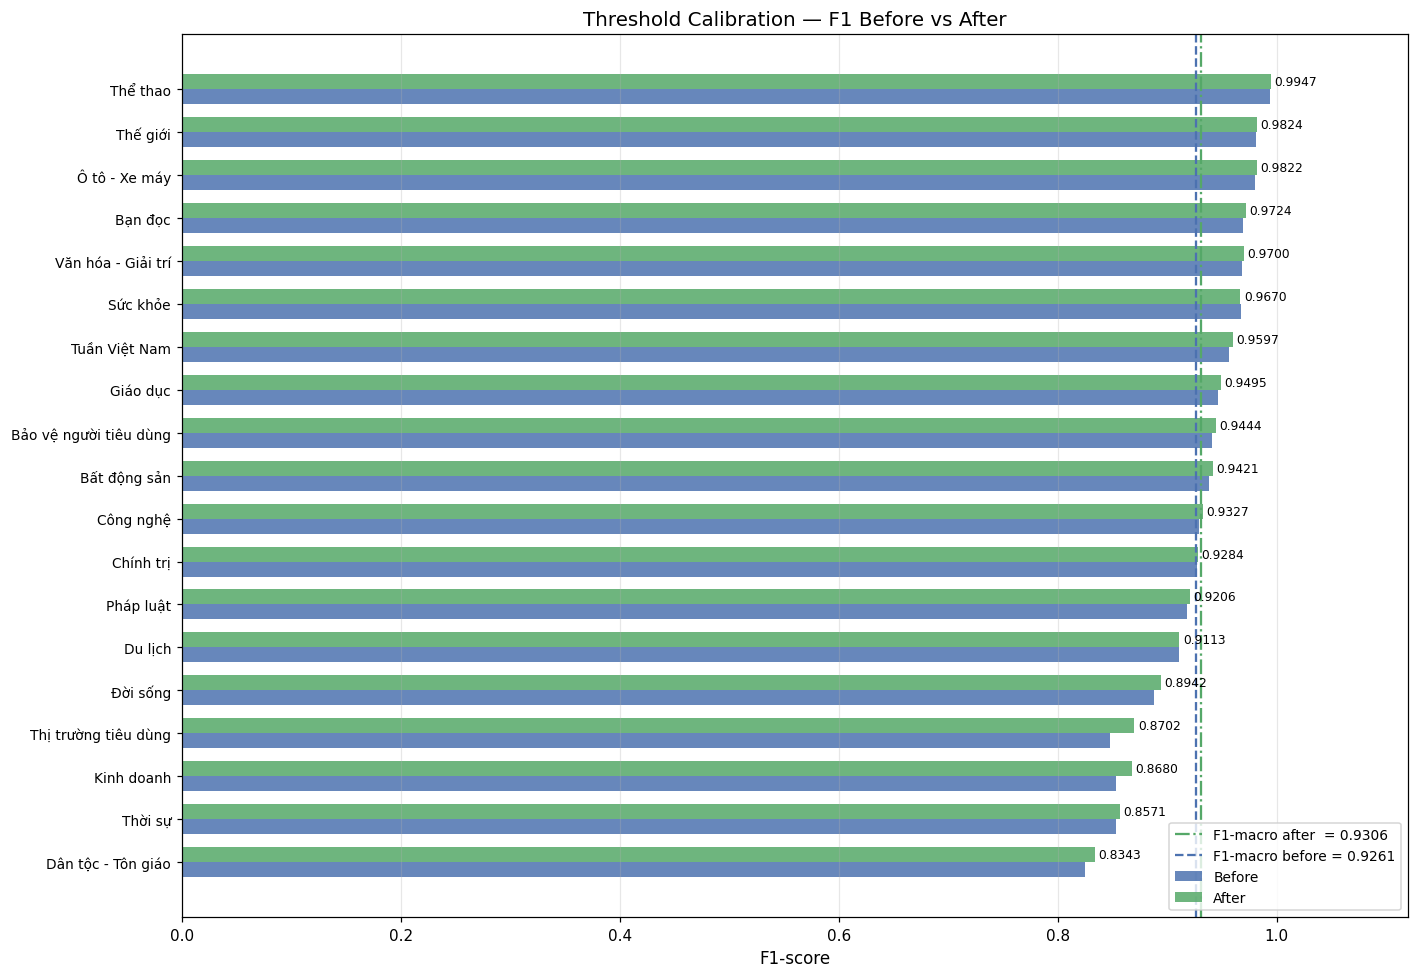

In [20]:
# ── 8.2 Visualize so sánh F1 before / after calibration ─────────────────────
_items_sorted = sorted(zip(classes, _base_f1, _cal_f1), key=lambda x: x[2])
_cls_names = [x[0] for x in _items_sorted]
_f1_before = [x[1] for x in _items_sorted]
_f1_after  = [x[2] for x in _items_sorted]

fig, ax = plt.subplots(figsize=(13, 9))
_y = np.arange(len(_cls_names))
_h = 0.35

_bars_b = ax.barh(_y - _h/2, _f1_before, _h, label="Before", color="#4C72B0", alpha=0.85)
_bars_a = ax.barh(_y + _h/2, _f1_after,  _h, label="After",  color="#55A868", alpha=0.85)

for bar, v in zip(_bars_a, _f1_after):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=8)

ax.set_yticks(_y); ax.set_yticklabels(_cls_names, fontsize=9)
ax.set_xlim(0, 1.12); ax.set_xlabel("F1-score", fontsize=11)
ax.axvline(cal_f1m,  color="#55A868", ls="-.", lw=1.5, label=f"F1-macro after  = {cal_f1m:.4f}")
ax.axvline(model_f1m, color="#4C72B0", ls="--",  lw=1.5, label=f"F1-macro before = {model_f1m:.4f}")
ax.set_title("Threshold Calibration — F1 Before vs After", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
save_fig(fig, "06_threshold_calibration.png")

In [21]:
# ── 8.3 Lưu thresholds vào model/ để app dùng ───────────────────────────────
_threshold_path = os.path.join(MODEL_DIR, "thresholds.json")

_threshold_config = {
    "method":      "per_class_f1_grid_search",
    "search_range": [0.3, 3.5],
    "n_grid":      200,
    "n_passes":    3,
    "usage":       "predict = argmax(softmax(logits) / thresholds)",
    "thresholds":  {cls: float(thresholds[i]) for i, cls in enumerate(classes)},
    "metrics_before": {"accuracy": model_acc, "f1_weighted": model_f1w, "f1_macro": model_f1m},
    "metrics_after":  {"accuracy": cal_acc,   "f1_weighted": cal_f1w,   "f1_macro": cal_f1m},
}
with open(_threshold_path, "w", encoding="utf-8") as f:
    json.dump(_threshold_config, f, ensure_ascii=False, indent=2)
log(f"Thresholds saved: {_threshold_path}", "SAVE")

# Cập nhật label_config.json để app biết có threshold
with open(LABEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    _lc = json.load(f)
_lc["threshold_file"] = "thresholds.json"
_lc["use_threshold_calibration"] = True
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_lc, f, ensure_ascii=False, indent=2)
log("label_config.json updated với threshold_file", "SAVE")

print(f"\n  [THRESHOLDS PER CLASS]")
print(f"  {'Class':<38}  {'Threshold':>10}  {'Ý nghĩa'}")
print(f"  {'─'*70}")
for i, cls in enumerate(classes):
    t = thresholds[i]
    if t > 1.2:   meaning = "Giảm over-prediction"
    elif t < 0.8: meaning = "Giảm under-prediction"
    else:         meaning = "Gần như không đổi"
    print(f"  {cls:<38}  {t:>10.4f}  {meaning}")

[16:56:53][ 210.2s] 💾 Thresholds saved: d:\Vietnamnet_News_Classification\PhoBERT\model\thresholds.json
[16:56:53][ 210.2s] 💾 label_config.json updated với threshold_file

  [THRESHOLDS PER CLASS]
  Class                                    Threshold  Ý nghĩa
  ──────────────────────────────────────────────────────────────────────
  Bạn đọc                                     3.4839  Giảm over-prediction
  Bảo vệ người tiêu dùng                      3.3714  Giảm over-prediction
  Bất động sản                                0.7181  Giảm under-prediction
  Chính trị                                   0.7020  Giảm under-prediction
  Công nghệ                                   0.6538  Giảm under-prediction
  Du lịch                                     1.4578  Giảm over-prediction
  Dân tộc - Tôn giáo                          2.4869  Giảm over-prediction
  Giáo dục                                    2.0206  Giảm over-prediction
  Kinh doanh                                  0.5734  Giảm under-